# 15.773 Homework 3: Vision Transformer

Student: Roman Burdakov


In [ ]:
pip install --upgrade keras-hub

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 10.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 79.1 MB/s eta 0:00:00
  Attempting uninstall: keras
    Found existing installation: keras 3.10.0
    Uninstalling keras-3.10.0:
      Successfully uninstalled keras-3.10.0
  Attempting uninstall: keras-hub
    Found existing installation: keras-hub 0.21.1
    Uninstalling keras-hub-0.21.1:
      Successfully uninstalled keras-hub-0.21.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
keras-nlp 0.21.1 requires keras-hub==0.21.1, but you have keras-hub 0.26.0 which is incompatible.


In [ ]:
import os
os.environ["KERAS_BACKEND"] = "jax"
os.environ["XLA_FLAGS"] = "--xla_gpu_deterministic_ops=true" # code to reduce random variation


import keras

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

keras.utils.set_random_seed(42)

## Make sure you choose the "High-RAM" option

Go to "Change runtime type" and make sure you have chosen the "High-Ram" option. Then run the code below to make sure it worked.


In [ ]:
gpu_info = !nvidia-smi
gpu_info = '\n'.join(gpu_info)
if gpu_info.find('failed') >= 0:
  print('Not connected to a GPU')
else:
  print(gpu_info)
  print("Successfully loaded GPU!")


from psutil import virtual_memory
ram_gb = virtual_memory().total / 1e9
print('Your runtime has {:.1f} gigabytes of available RAM\n'.format(ram_gb))

if ram_gb < 20:
  print('Not using a high-RAM runtime')
else:
  print('You are using a high-RAM runtime!')

Sun Mar  1 16:51:57 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-80GB          Off |   00000000:00:05.0 Off |                    0 |
| N/A   33C    P0             52W /  400W |       0MiB /  81920MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

# Introduction

Your goal in this exercise is to detect emotion from a facial image. To that end, we will use the 2013 Facial Expression Recognition (FER) dataset.

The dataset consists of ~36,000 images, each annotated with one of seven labels:
* angry
* disgust
* fear
* happy
* sad
* surprise
* neutral

The goal of this homework assignment is to walk you through how to use transfer learning with a Vision Transformer (ViT) model to detect emotion in facial images.

But first, let's get the data.

In [ ]:
# download the dataset
!wget -q -O fer2013.csv -P ./ "https://dl.dropbox.com/scl/fi/e2ik6aryemboameq1rwwn/fer2013.csv?rlkey=ux7tyge6flk9nnuul9desizgf&dl=0"

The data has 35887 rows and 3 columns:
* Emotion - encoded as the numbers 0 (anger) through 6 (neutral)
* Pixels - A space-separated list of numbers representing the pixels of this image.
* Usage - No need to worry about this column

In [ ]:
data = pd.read_csv('fer2013.csv')
data

,emotion,pixels,Usage
0,0,70 80 82 72 58 58 60 63 54 58 60 48 89 115 121...,Training
1,0,151 150 147 155 148 133 111 140 170 174 182 15...,Training
2,2,231 212 156 164 174 138 161 173 182 200 106 38...,Training
3,4,24 32 36 30 32 23 19 20 30 41 21 22 32 34 21 1...,Training
4,6,4 0 0 0 0 0 0 0 0 0 0 0 3 15 23 28 48 50 58 84...,Training
...,...,...,...
35882,6,50 36 17 22 23 29 33 39 34 37 37 37 39 43 48 5...,PrivateTest
35883,3,178 174 172 173 181 188 191 194 196 199 200 20...,PrivateTest
35884,0,17 17 16 23 28 22 19 17 25 26 20 24 31 19 27 9...,PrivateTest
35885,3,30 28 28 29 31 30 42 68 79 81 77 67 67 71 63 6...,PrivateTest


The pixel values for each image is provided as a space-separated list of numbers. How many pixels in an image?

In [ ]:
len(data.loc[0, 'pixels'].split(' '))

2304

### Pre-Processing the Pixels (Independent Variable)

Each image is encoded as a list of 2304 pixels. We will reshape this into an 48x48 image next.

Recall that a color image is represented as a tensor of dimension N by M by 3, where the 3 represents the 3 colors (red, green and blue). Our images from the FER 2013 dataset are grayscale images, with only a single channel representing the amount of black in the image. This is inconvenient to work with because many pre-trained models used in transfer learning require the input image to have 3 colors.

To get around this, we will take each image, which is a 48 x 48 tensor, and transform it into a 48 x 48 x 3 tensor by simply duplicating it three times. We can think of a greyscale image as one where the red, green and blue 'tables' are exactly the same.

The following code transforms our dataset into a tensor of shape (35887, 48, 48, 3): a list of 35887 images, each of which is a (48, 48, 3)-shape tensor.

In [ ]:
pixels = data['pixels'].tolist()
width, height = 48, 48
faces = []
for pixel_sequence in pixels:
    face = [int(pixel) for pixel in pixel_sequence.split(' ')] # read each face as a 1-d array
    face = np.asarray(face).reshape(width, height) # reshape the length 2304 1-d array into an 48x48 array
    face = np.stack((face,)*3, axis=-1)
    faces.append(face.astype('float32'))

faces = np.asarray(faces)
faces.shape

(35887, 48, 48, 3)

For the first image, i.e. `faces[0]`, we can examine its first table (corresponding to "red").

In [ ]:
faces[0, :, :, 0]

array([[ 70.,  80.,  82., ...,  52.,  43.,  41.],
       [ 65.,  61.,  58., ...,  56.,  52.,  44.],
       [ 50.,  43.,  54., ...,  49.,  56.,  47.],
       ...,
       [ 91.,  65.,  42., ...,  72.,  56.,  43.],
       [ 77.,  82.,  79., ..., 105.,  70.,  46.],
       [ 77.,  72.,  84., ..., 106., 109.,  82.]], dtype=float32)

This is the exact same as the second table (corresponding to "blue"). And similarly for green.

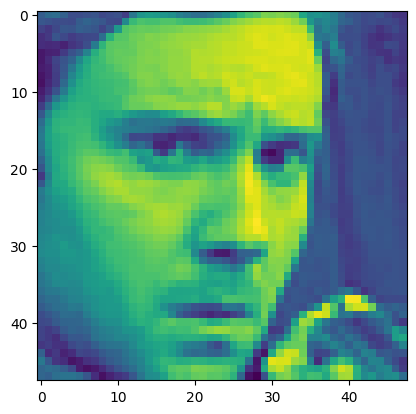

array([[ 70.,  80.,  82., ...,  52.,  43.,  41.],
       [ 65.,  61.,  58., ...,  56.,  52.,  44.],
       [ 50.,  43.,  54., ...,  49.,  56.,  47.],
       ...,
       [ 91.,  65.,  42., ...,  72.,  56.,  43.],
       [ 77.,  82.,  79., ..., 105.,  70.,  46.],
       [ 77.,  72.,  84., ..., 106., 109.,  82.]], dtype=float32)

In [ ]:
# show image
plt.imshow(faces[0, :, :, 1].astype('uint8'))
plt.show()
faces[0, :, :, 1]

### Pre-Processing for Emotions (Dependent Variable)

Next, let's take a look at how emotion (the dependent variable) is encoded. We have that 0 = 'angry', 1 = 'disgust', ... 6 = 'neutral'.

In [ ]:
data.emotion.unique()

array([0, 2, 4, 6, 3, 5, 1])

We will convert emotion to a one-hot encoding using the `pd.get_dummies` function.

In [ ]:
emotions = pd.get_dummies(data['emotion']).to_numpy() # each emotion is 'one-hot' encoded as a 7-dim vector
emotions_names = ('angry', 'disgust', 'fear', 'happy', 'sad', 'surprise', 'neutral')
emotions.shape

(35887, 7)

### Example Images
Lets take a look at some of these fun images!

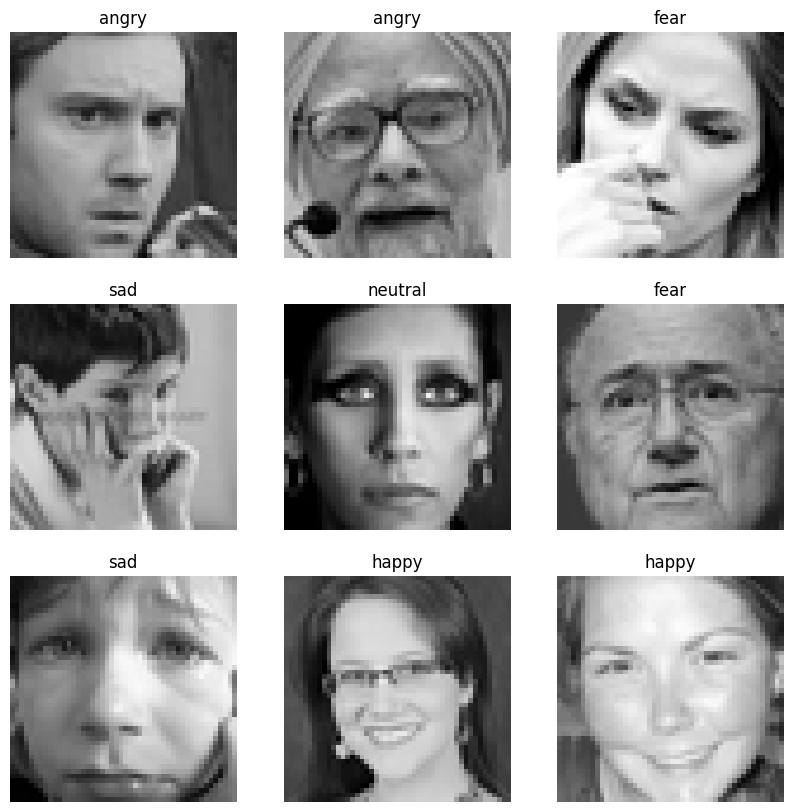

In [ ]:
fig = plt.figure(figsize=(10, 10))
for i in range(9):
    ax = fig.add_subplot(3, 3, i+1)
    ax.set_title(f"{emotions_names[np.argmax(emotions[i])]}")
    ax.imshow(faces[i].astype('uint8'))
    ax.axis('off')

### Train/Test Split
As in the original dataset, we will reserve the first 28,709 images for training and the rest for testing.

In [ ]:
train_faces, train_emotions =  faces[:28709], emotions[:28709]
test_faces, test_emotions =  faces[28709:], emotions[28709:]

train_faces.shape, train_emotions.shape, test_faces.shape, test_emotions.shape

((28709, 48, 48, 3), (28709, 7), (7178, 48, 48, 3), (7178, 7))

# Problem 1: Transfer Learning with Frozen Vision Transformer Model [30 Points]
In this problem, we will build an emotion classifier using a pre-trained Vision Transformer backbone with our own custom classification head. In this part of the HW, we'll keep the backbone frozen and only train the classification head.


## Part (a): Building the Model [10 points]
We'll use the ViT backbone with a classification head for 7 emotion classes.


In [ ]:
import keras_hub

In [ ]:
# Download the ViT backbone and preprocessor
backbone = keras_hub.models.Backbone.from_preset("vit_base_patch16_224_imagenet")
preprocessor = keras_hub.models.ViTImageClassifierPreprocessor.from_preset("vit_base_patch16_224_imagenet")

Write a single line of code to 'freeze' the backbone.

In [ ]:
### YOUR CODE HERE ###
backbone.trainable = False

Define a classification head with a dense layer of 256 ReLU neurons, followed by a Dropout layer with probability of 0.5, and finally a softmax with 7 outputs (since we have 7 emotions to detect). Use the embedding of the CLS token as the input to the classification head.
Feel free to refer to the Lecture 8 Colab as you do this.

**Hint**: Use `keras.layers.Dropout(0.5)(x)` for the dropout layer

In [ ]:
# Create the model
inputs = keras.Input(shape=(48, 48, 3), name="input")
#######################
### YOUR CODE HERE ###

x = preprocessor(inputs)                                                  # Preprocess input for ViT
x = backbone(x)[:, 0, :]                                                  # Run through ViT backbone, select CLS embedding
x = keras.layers.Dense(256, activation="relu")(x)                         # Run through a dense layer
x = keras.layers.Dropout(0.5)(x)                                          # Apply dropout
outputs = keras.layers.Dense(emotions.shape[1], activation="softmax")(x)  # Final classification layer

model = keras.Model(inputs, outputs)

#######################
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 48, 48, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vi_t_image_classifier_preproce… │ (None, 224, 224, 3)    │             0 │
│ (ViTImageClassifierPreprocesso… │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vi_t_backbone (ViTBackbone)     │ (None, 197, 768)       │    85,798,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ get_item (GetItem)              │ (None, 768)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       196,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 85,997,319 (328.05 MB)

 Trainable params: 198,663 (776.03 KB)

 Non-trainable params: 85,798,656 (327.30 MB)


## Part (b): Number of Parameters [10 points]

* How many total parameters does the the model contain?
* How many are trainable?
* Hand-calculate the number of trainable parameters

<font color='red'> **Your answers:** </font>

1. _Total params: 85,997,319_
2. _Trainable params: 198,663_
3. Hand calculation for trainable parameters:
* _Input Dense output: 256 (input is 768-dim CLS token)_
* _Weights: 768*256 = 196,608_
* _Biases: = 256_
* _Total: 196,608 + 256 = **196,864**_
* _Output Dense output: 7_
* _Weights: 256*7 = 1,792_
* _Biases: = 7_
* _Total: 1,792 + 7 = **1,799**_
* _Dropout: 0 params_
* _Total trainable = 196,864 + 1,799 = **198,663**_

## Part (c): Training and Evaluation [10 points]

Let us compile our model and fit it on the training data. Since we one-hot-encoded the dependent variable, we use `categorical_crossentropy`, not `sparse_categorical_crossentropy`.

Fill in the parameters of `model.compile` and `model.fit` below.

* Compile the model using the `categorical_crossentropy` loss, `adam` optimizer with `learning_rate=1e-4` and report the `accuracy` metric.
* Fit the model on `train_faces`, `train_emotions` using a batch size of 64, for 5 epochs and a validation split of 20%.


In [ ]:
model.compile(
#######################
### YOUR CODE HERE ###
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
#######################
)

In [ ]:
model_history = model.fit(
#######################
### YOUR CODE HERE ###
    train_faces,
    train_emotions,
    epochs=5,
    batch_size=64,
    validation_split=0.2
#######################
)

Epoch 1/5
359/359 ━━━━━━━━━━━━━━━━━━━━ 105s 265ms/step - accuracy: 0.4175 - loss: 1.5972 - val_accuracy: 0.5427 - val_loss: 1.2497
Epoch 2/5
359/359 ━━━━━━━━━━━━━━━━━━━━ 84s 227ms/step - accuracy: 0.5062 - loss: 1.3184 - val_accuracy: 0.5684 - val_loss: 1.1746
Epoch 3/5
359/359 ━━━━━━━━━━━━━━━━━━━━ 84s 227ms/step - accuracy: 0.5356 - loss: 1.2427 - val_accuracy: 0.5824 - val_loss: 1.1400
Epoch 4/5
359/359 ━━━━━━━━━━━━━━━━━━━━ 84s 227ms/step - accuracy: 0.5558 - loss: 1.1981 - val_accuracy: 0.5944 - val_loss: 1.1081
Epoch 5/5
359/359 ━━━━━━━━━━━━━━━━━━━━ 84s 227ms/step - accuracy: 0.5677 - loss: 1.1569 - val_accuracy: 0.5989 - val_loss: 1.0864


## Part (d) Interpret the confusion matrix [10 points]

Let's calculate the **confusion matrix**.

The function `show_confusion_matrix` has been written for you below. You can apply it to any Keras Model for classification and it will calculate:
* Test accuracy
* A _confusion matrix_: Each row of the confusion matrix has the predicted labels and each column has the actual labels. For example, if the element in row `happy` and column `sad` is 92, that means there are 92 data points in the test set where the true label is `sad` but we predicted `happy`.
* A normalized version of the confusion matrix, where each column is normalized to add up to 100%.

In [ ]:
from sklearn import metrics

from IPython.display import display

def show_confusion_matrix(model):
    """
    Calculates the test accuracy, confusion matrix and heat map for a model.
    """
    global test_faces, test_emotions, emotions_names

    y_pred = model.predict(test_faces).argmax(axis=1)
    y_actual = test_emotions.argmax(axis=1)

    print('*************************\n* Test Accuracy: %.4f *\n*************************' % metrics.accuracy_score(y_actual, y_pred))

    cm = pd.DataFrame(metrics.confusion_matrix(y_pred, y_actual), index=emotions_names, columns=emotions_names)
    display(cm)

    cm = 100*cm.div(cm.sum(axis=0), axis=1)
    display(cm)

show_confusion_matrix(model)

225/225 ━━━━━━━━━━━━━━━━━━━━ 30s 107ms/step
*************************
* Test Accuracy: 0.5843 *
*************************


,angry,disgust,fear,happy,sad,surprise,neutral
angry,422,42,153,68,153,63,54
disgust,0,2,1,0,0,0,0
fear,86,21,307,26,118,90,73
happy,104,16,67,1512,92,51,108
sad,182,14,263,46,642,18,218
surprise,42,2,106,46,12,552,23
neutral,122,14,127,76,230,57,757


,angry,disgust,fear,happy,sad,surprise,neutral
angry,44.050104,37.837838,14.941406,3.833145,12.269447,7.581227,4.379562
disgust,0.000000,1.801802,0.097656,0.000000,0.000000,0.000000,0.000000
fear,8.977035,18.918919,29.980469,1.465614,9.462711,10.830325,5.920519
happy,10.855950,14.414414,6.542969,85.231116,7.377706,6.137184,8.759124
sad,18.997912,12.612613,25.683594,2.593010,51.483561,2.166065,17.680454
surprise,4.384134,1.801802,10.351562,2.593010,0.962310,66.425993,1.865369
neutral,12.734864,12.612613,12.402344,4.284104,18.444266,6.859206,61.394972


QUESTIONS

* What is the model's overall accuracy?
* What is the model's accuracy when the actual label is 'happy`?
* What is the emotion for which the model is least accurate i.e., when the true label is that emotion, the model has the lowest accuracy?



<font color='red'> **Your answers:** </font>

* _The model's overall accuracy is: **58.43%**_
* _The model's accuracy for true `happy` image classification is: **85.23%**_
* _The least accurate emotion classifiction for this model is for `disgust`. Accuracy: **1.8%**_

# Problem 2: Transfer Learning with Unfrozen Backbone [50 Points]

We'll use the same model architecture as in Problem 1, but this time we'll allow the backbone weights to be updated during training i.e., we will unfreeze the backbone.

In Part (a), we will use the same learning rate as in Problem 1. In Part (b), we will experiment with a lower learning rate.


## Part (a): Fine-Tuning with Standard Learning Rate [25 points]


In [ ]:
# Fresh instance of pre-trained backbone
backbone = keras_hub.models.Backbone.from_preset("vit_base_patch16_224_imagenet", load_weights=True)

# Create model with the same architecture
inputs = keras.Input(shape=(48, 48, 3), name="input")
#######################
### YOUR CODE HERE ###
x = preprocessor(inputs)                                                  # Preprocess input for ViT
x = backbone(x)[:, 0, :]                                                  # Run through ViT backbone, select CLS embedding
x = keras.layers.Dense(256, activation="relu")(x)                         # Run through a dense layer
x = keras.layers.Dropout(0.5)(x)                                          # Apply dropout
outputs = keras.layers.Dense(emotions.shape[1], activation="softmax")(x)  # Final classification layer

#######################
fine_tuned_model = keras.Model(inputs, outputs, name='fine_tuned_vit')

fine_tuned_model.summary()

Model: "fine_tuned_vit"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 48, 48, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vi_t_image_classifier_preproce… │ (None, 224, 224, 3)    │             0 │
│ (ViTImageClassifierPreprocesso… │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vi_t_backbone (ViTBackbone)     │ (None, 197, 768)       │    85,798,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ get_item_1 (GetItem)            │ (None, 768)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       196,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_25 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 85,997,319 (328.05 MB)

 Trainable params: 85,997,319 (328.05 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Train with same parameters
fine_tuned_model.compile(
#######################
### YOUR CODE HERE ###
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
#######################
)

fine_tuned_model_history = fine_tuned_model.fit(
#######################
### YOUR CODE HERE ###
    train_faces,
    train_emotions,
    epochs=5,
    batch_size=64,
    validation_split=0.2
#######################
 )

Epoch 1/5
359/359 ━━━━━━━━━━━━━━━━━━━━ 268s 683ms/step - accuracy: 0.5548 - loss: 1.1965 - val_accuracy: 0.6661 - val_loss: 0.9096
Epoch 2/5
359/359 ━━━━━━━━━━━━━━━━━━━━ 218s 607ms/step - accuracy: 0.6684 - loss: 0.9027 - val_accuracy: 0.6719 - val_loss: 0.8882
Epoch 3/5
359/359 ━━━━━━━━━━━━━━━━━━━━ 218s 607ms/step - accuracy: 0.7399 - loss: 0.7189 - val_accuracy: 0.6761 - val_loss: 0.8792
Epoch 4/5
359/359 ━━━━━━━━━━━━━━━━━━━━ 218s 607ms/step - accuracy: 0.8097 - loss: 0.5357 - val_accuracy: 0.6904 - val_loss: 0.9308
Epoch 5/5
359/359 ━━━━━━━━━━━━━━━━━━━━ 218s 607ms/step - accuracy: 0.8731 - loss: 0.3693 - val_accuracy: 0.6808 - val_loss: 1.0908


In [ ]:
show_confusion_matrix(fine_tuned_model)

225/225 ━━━━━━━━━━━━━━━━━━━━ 29s 104ms/step
*************************
* Test Accuracy: 0.6785 *
*************************


,angry,disgust,fear,happy,sad,surprise,neutral
angry,569,34,88,39,116,14,56
disgust,3,52,2,1,3,0,0
fear,140,13,597,48,226,97,93
happy,37,4,20,1550,56,27,80
sad,113,3,156,35,652,5,200
surprise,26,1,88,34,26,677,31
neutral,70,4,73,67,168,11,773


,angry,disgust,fear,happy,sad,surprise,neutral
angry,59.394572,30.630631,8.593750,2.198422,9.302326,1.684717,4.541768
disgust,0.313152,46.846847,0.195312,0.056370,0.240577,0.000000,0.000000
fear,14.613779,11.711712,58.300781,2.705750,18.123496,11.672684,7.542579
happy,3.862213,3.603604,1.953125,87.373168,4.490778,3.249097,6.488240
sad,11.795407,2.702703,15.234375,1.972943,52.285485,0.601685,16.220600
surprise,2.713987,0.900901,8.593750,1.916573,2.085004,81.468111,2.514193
neutral,7.306889,3.603604,7.128906,3.776776,13.472334,1.323706,62.692620


QUESTIONS

* What is the model's overall accuracy?
* Did the model's ability to detect `disgust` improve relative to the model from Problem 1? What was the improvement?

<font color='red'> **Your answers:** </font>

* _The model's overall accuracy is: **67.85%** (~16.12% improvement over prev. model)_
* _The model's accuracy for `disgust` has improved a lot from 1.8% to **46.85%**_

## Part (b): Fine-Tuning with Lower Learning Rate [25 points]
When fine-tuning a pre-trained model, it's often beneficial to use a lower learning rate to not alter the pretrained weights too much. Let's try the same model as before but with a reduced learning rate: when you `compile` the model below, use a learning rate of 1e-5 (rather than 1e-4).

In [ ]:
# Fresh instance of pre-trained backbone
backbone = keras_hub.models.Backbone.from_preset("vit_base_patch16_224_imagenet", load_weights=True)

# Create model with the same architecture
inputs = keras.Input(shape=(48, 48, 3), name="input")
#######################
### YOUR CODE HERE ###
x = preprocessor(inputs)                                                  # Preprocess input for ViT
x = backbone(x)[:, 0, :]                                                  # Run through ViT backbone, select CLS embedding
x = keras.layers.Dense(256, activation="relu")(x)                         # Run through a dense layer
x = keras.layers.Dropout(0.5)(x)                                          # Apply dropout
outputs = keras.layers.Dense(emotions.shape[1], activation="softmax")(x)  # Final classification layer

#######################
fine_tuned_model_lr = keras.Model(inputs, outputs, name='fine_tuned_vit_lower_lr')

fine_tuned_model_lr.summary()

Model: "fine_tuned_vit_lower_lr"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 48, 48, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vi_t_image_classifier_preproce… │ (None, 224, 224, 3)    │             0 │
│ (ViTImageClassifierPreprocesso… │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vi_t_backbone (ViTBackbone)     │ (None, 197, 768)       │    85,798,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ get_item_2 (GetItem)            │ (None, 768)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       196,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_38 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 85,997,319 (328.05 MB)

 Trainable params: 85,997,319 (328.05 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Compile with learning rate of 1e-5
fine_tuned_model_lr.compile(
#######################
### YOUR CODE HERE ###
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
#######################
)

# Train the model
fine_tuned_model_lr_history = fine_tuned_model_lr.fit(
#######################
### YOUR CODE HERE ###
    train_faces,
    train_emotions,
    epochs=5,
    batch_size=64,
    validation_split=0.2
#######################
)

Epoch 1/5
359/359 ━━━━━━━━━━━━━━━━━━━━ 268s 684ms/step - accuracy: 0.4549 - loss: 1.4926 - val_accuracy: 0.5953 - val_loss: 1.0980
Epoch 2/5
359/359 ━━━━━━━━━━━━━━━━━━━━ 218s 607ms/step - accuracy: 0.5846 - loss: 1.1198 - val_accuracy: 0.6371 - val_loss: 0.9821
Epoch 3/5
359/359 ━━━━━━━━━━━━━━━━━━━━ 218s 607ms/step - accuracy: 0.6301 - loss: 1.0010 - val_accuracy: 0.6529 - val_loss: 0.9381
Epoch 4/5
359/359 ━━━━━━━━━━━━━━━━━━━━ 218s 607ms/step - accuracy: 0.6683 - loss: 0.9108 - val_accuracy: 0.6674 - val_loss: 0.8923
Epoch 5/5
359/359 ━━━━━━━━━━━━━━━━━━━━ 218s 607ms/step - accuracy: 0.7004 - loss: 0.8234 - val_accuracy: 0.6752 - val_loss: 0.8900


In [ ]:
show_confusion_matrix(fine_tuned_model_lr)

225/225 ━━━━━━━━━━━━━━━━━━━━ 29s 104ms/step
*************************
* Test Accuracy: 0.6616 *
*************************


,angry,disgust,fear,happy,sad,surprise,neutral
angry,528,47,114,23,133,26,44
disgust,1,22,2,0,2,0,1
fear,94,11,419,21,117,52,47
happy,62,6,39,1596,62,32,92
sad,129,15,216,20,641,14,167
surprise,32,3,125,41,20,677,16
neutral,112,7,109,73,272,30,866


,angry,disgust,fear,happy,sad,surprise,neutral
angry,55.114823,42.342342,11.132812,1.296505,10.665597,3.128761,3.568532
disgust,0.104384,19.819820,0.195312,0.000000,0.160385,0.000000,0.081103
fear,9.812109,9.909910,40.917969,1.183766,9.382518,6.257521,3.811841
happy,6.471816,5.405405,3.808594,89.966178,4.971933,3.850782,7.461476
sad,13.465553,13.513514,21.093750,1.127396,51.403368,1.684717,13.544201
surprise,3.340292,2.702703,12.207031,2.311161,1.603849,81.468111,1.297648
neutral,11.691023,6.306306,10.644531,4.114994,21.812350,3.610108,70.235199


QUESTIONS

* What is the model's overall accuracy? How does it compare to the model in Problem 2(a) that used a higher learning rate?
* Did the model's ability to detect `disgust` improve or worsen relative to the model from Problem 2(a)?

<font color='red'> **Your answers:** </font>

* _The model's overall accuracy is: **66.16%**, which is slightly worse compare to the previous model (2a) accuracy of 67.85%_
* _The model's predicting ability for `disgust` worsen - accuracy has dropped to **19.82%** (which is a significant -57.69% drop).

_Note: 5 epochs may be too few for lr=1e-5 to converge sufficiently — the val_loss is still decreasing at epoch 5, suggesting more epochs would help_

# Problem 3: Concept Checks [10 Points]


 1. Briefly explain the relationship between an epoch and a batch in stochastic gradient descent.

<font color='red'>
An epoch is one full pass over the training set.
A batch is the chunk of examples you process at once to produce a single gradient update.
With SGD/mini-batch SGD, you don’t compute the gradient using the whole dataset each step. You compute it on one batch, update the weights, then move to the next batch. So one epoch contains about (number of training examples) / (batch size) updates.

Using batches keeps training manageable on hardware and the added randomness in the gradient can sometimes help optimization.</font>

2. When we ran `model.fit`, we saw that there are 359 batches per epoch. Please explain how this 359 is calculated. _Hint_: There are 28,709 training data points and 20% is set aside for validation.

<font color='red'>**359 is computed as 28,709 * 0.8 / 64 = 358.8625, so we take ceiling - 359 - as we can't use fractional answer for number of batches. Here, 28,709 is the total number of samples; 80% are used for training, with 64 samples per batch.**</font>